In [1]:
import yfinance as yf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis, describe, norm
from scipy.special import lambertw

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

# Download Data
S&P 500 from 2006/01/01 to 2025/12/31. Ticker: ^GSPC.

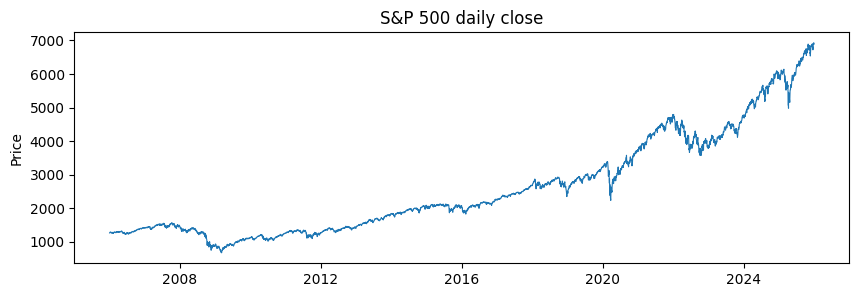

In [2]:
df = yf.download("^GSPC", start="2006-01-01", end="2025-12-31", auto_adjust=True, progress=False)
price = df["Close"].squeeze()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(price.index, price.values, linewidth=0.8)
ax.set_title("S&P 500 daily close")
ax.set_ylabel("Price")
plt.show()

# **Pre-Processing**

# Log-Returns

$$
r_t = \log\frac{s_t}{s_{t-1}} = \log s_t - \log s_{t-1}, \qquad t = 1, \dots,T
$$

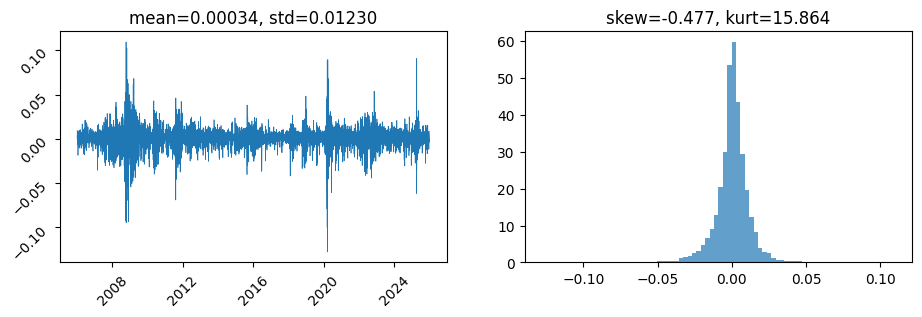

In [3]:
log_ret = np.log(price/price.shift(1)).dropna()

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(log_ret.index, log_ret, linewidth=0.5)
ax[0].set_title(f"mean={log_ret.mean():.5f}, std={log_ret.std():.5f}")
ax[0].tick_params(labelrotation=45)
ax[1].hist(log_ret, bins=80, density=True, alpha=0.7)
ax[1].set_title(f"skew={skew(log_ret):.3f}, kurt={kurtosis(log_ret, fisher=False):.3f}")
plt.show()

# First Standardization

In [4]:
log_ret = np.log(price/price.shift(1)).dropna().values

mu1 = np.mean(log_ret)
sigma1 = np.std(log_ret, ddof=1)

r1 = (log_ret-mu1)/sigma1

print(f"Standardization: mean={np.mean(r1):.3e}, std={np.std(r1, ddof=1):.3f}, "
      f"kurtosis={kurtosis(r1, fisher=False):.3f}")

Standardization: mean=-1.060e-17, std=1.000, kurtosis=15.864


# Lambert W transformation

In [5]:
def inverse_lambert_w(y, delta):
  if delta <= 0:
    return y.copy()

  z = delta * y**2
  w = np.real(lambertw(z, k=0))
  return np.sign(y) * np.sqrt(w / delta)

def forward_lambert_w(u, delta):
  return u * np.exp(1/2 * delta * u**2)

def igmm(y, max_iter=200, tol=1e-09):
  """
  Iterative Generalized Method of Moments for the delta parameter
  of the heavy-tailed Lambert W x Gaussian distribution.
  """
  mu, sigma = y.mean(), y.std(ddof=1)
  z = (y - mu) / sigma
  delta = 0.0
  for _ in range(max_iter):
      u = inverse_lambert_w(z, delta) if delta > 0 else z
      gamma = kurtosis(u, fisher=True)
      delta_new = delta + 0.5 * np.log1p(max(gamma, 0.0) / 66.0)
      delta_new = float(np.clip(delta_new, 0.0, 0.49))
      if abs(delta_new - delta) < tol:
          delta = delta_new
          break
      delta = delta_new
  return delta

In [6]:
delta_hat = igmm(r1)
print(f"Delta for the LambertW transform: {delta_hat}")

u1 = inverse_lambert_w(r1, delta_hat)

Delta for the LambertW transform: 0.49


# Second Standardization
Re-standardize, because the Lambert W transform only enforces kurtosis matching. The mean and variance can drift slightly, so we standardize again.

In [7]:
mu2, sigma2 = u1.mean(), u1.std(ddof=1)
u2 = (u1 - mu2) / sigma2
print(f"Mean={u2.mean():.3e}, std={u2.std():.3f}, "
      f"kurt={kurtosis(u2, fisher=False):.3f}")

Mean=-1.837e-17, std=1.000, kurt=3.381


In [8]:
data = {
    "Time Series": ["Std_1 (r1)", "LambertW (u1)", "Std_2 (u2)"],
    "Mean": [r1.mean(), u1.mean(), u2.mean()],
    "Std": [r1.std(), u1.std(), u2.std()],
    "Min": [r1.min(), u1.min(), u2.min()],
    "Max": [r1.max(), u1.max(), u2.max()],
    "Kurtosis": [kurtosis(r1, fisher=False), kurtosis(u1, fisher=False), kurtosis(u2, fisher=False)],
    "Skewness": [skew(r1), skew(u1), skew(u2)]
}

df = pd.DataFrame(data).set_index("Time Series")
format_dict = {
    'Mean': '{:.3e}', 'Std': '{:.3f}', 'Min': '{:.3f}',
    'Max': '{:.3f}', 'Kurtosis': '{:.3f}', 'Skewness': '{:.3f}'
}

print(df)

                       Mean       Std        Min       Max   Kurtosis  \
Time Series                                                             
Std_1 (r1)    -1.059668e-17  0.999901 -10.405849  8.881138  15.864366   
LambertW (u1)  1.335030e-02  0.643005  -2.434851  2.335078   3.381397   
Std_2 (u2)    -1.836758e-17  0.999901  -3.807061  3.610389   3.381397   

               Skewness  
Time Series              
Std_1 (r1)    -0.477050  
LambertW (u1) -0.194381  
Std_2 (u2)    -0.194381  


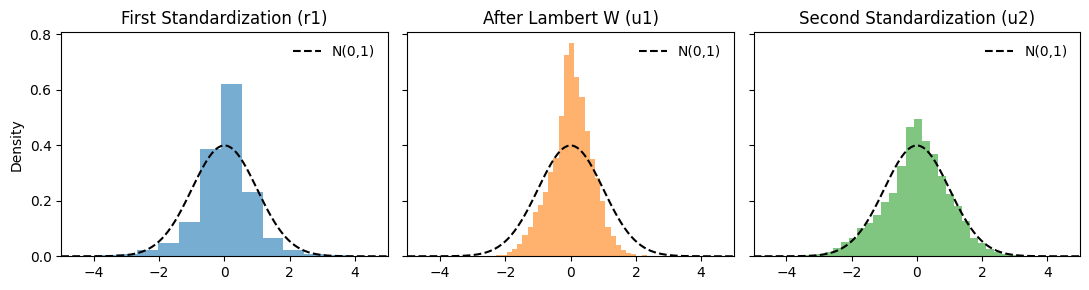

In [9]:
xs = np.linspace(-5, 5, 300)
gaussian_pdf = norm.pdf(xs, loc=0, scale=1)

fig, ax = plt.subplots(1, 3, figsize=(11, 3), sharey=True)

ax[0].hist(r1, bins=30, density=True, alpha=0.6, color="C0")
ax[0].plot(xs, gaussian_pdf, 'k--', lw=1.5, label='N(0,1)')
ax[0].set_xlim(-5, 5)
ax[0].set_title("First Standardization (r1)")
ax[0].set_ylabel("Density")
ax[0].legend(frameon=False)

ax[1].hist(u1, bins=30, density=True, alpha=0.6, color="C1")
ax[1].plot(xs, gaussian_pdf, 'k--', lw=1.5, label='N(0,1)')
ax[1].set_xlim(-5, 5)
ax[1].set_title("After Lambert W (u1)")
ax[1].legend(frameon=False)

ax[2].hist(u2, bins=30, density=True, alpha=0.6, color="C2")
ax[2].plot(xs, gaussian_pdf, 'k--', lw=1.5, label='N(0,1)')
ax[2].set_xlim(-5, 5)
ax[2].set_title("Second Standardization (u2)")
ax[2].legend(frameon=False)

plt.tight_layout()
plt.show()

We standardized the log-returns $r_1$ and applied the inverse Lambert W transform to remove the fat tails (heavy outliers), obtaining $u_1$.
Then we standardized again so that the distribution is as close as possible to a Gaussian: $u_2$.

# Rolling Windows
Of 30 days, even though 30 trading days are more than 30 calendar days, which are used in the expiry of a European call.

(5000, 30)
tensor([[ 0.3929, -0.0613,  1.0043,  0.3910, -0.1083,  0.3700, -0.8080,  0.0888,
         -0.5116, -0.5424,  0.6120, -1.7682,  0.1693,  0.2387, -0.2793,  0.7919,
          0.8459,  0.0813, -0.5516,  0.1708, -1.0848, -0.7088,  0.0356, -0.9931,
          0.9346, -0.2490,  0.2553, -0.4670,  1.0622,  0.3727]])


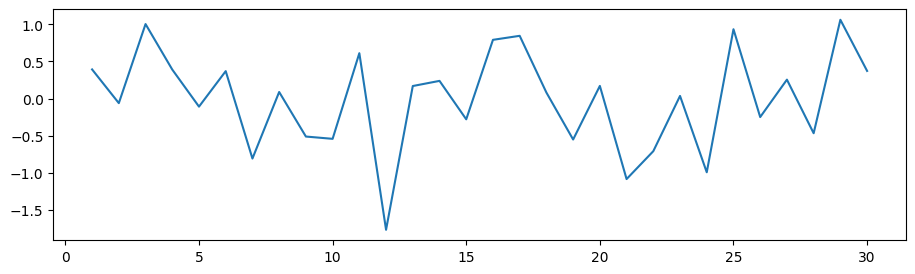

In [10]:
days = 30

def rolling_windows(x, T):
    '''
    Return array of shape (N, T) of stride-1 sub-sequences.
    '''
    N = len(x) - T + 1
    return np.lib.stride_tricks.sliding_window_view(x, T).copy()

windows = rolling_windows(u2, days)
print(windows.shape)

X_real = torch.tensor(windows, dtype=torch.float32).unsqueeze(1)
print(X_real[0])

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(np.arange(1, 31), X_real[0].squeeze(0))
plt.show()

# **Quant GAN Training**
GAN objective:

$$
\min_\theta \max_\eta\ \mathbb{E}_{x \sim p_{\text{data}}}[\log d_\eta(x)] + \mathbb{E}_{z \sim \mathcal{N}(0, I)}[\log(1 - d_\eta(g_\theta(z)))].
$$

We alternate updates of $\eta$ and $\theta$ via Adam (or RMSProp).

# Generator and Critic are Temporal Convolutional Networks (TCNs)
TCN is a stack of *dilated causal* 1-D convolutions.


*   Dilated: so the receptive field grows exponentially with depth.
*   Causal: so output at time $t$ depends only on inputs at times $\le t$.

CausalConv1d -> TempBlock -> TCN


In [11]:
class CausalConv1d(nn.Module):
    '''1D conv with causal padding.'''
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=self.pad, dilation=dilation)
    def forward(self, x):
        out = self.conv(x)
        return out[:, :, :-self.pad] if self.pad > 0 else out

class TempBlock(nn.Module):
    '''Two causal dilated convolutions with PReLU activations.'''
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.0):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch, out_ch, kernel_size, dilation)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.act1 = nn.PReLU(out_ch)
        self.act2 = nn.PReLU(out_ch)
        self.drop = nn.Dropout(dropout)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        out = self.act1(self.conv1(x))
        out = self.drop(out)
        out = self.act2(self.conv2(out))
        out = self.drop(out)
        return out + self.skip(x)

class TCN(nn.Module):
    '''Stack of 5 temporal blocks with dilations 1, 2, 4, ..., 2^{L-1}.'''
    def __init__(self, in_ch, out_ch, hidden=64, n_layers=5, kernel_size=2, dropout=0.0):
        super().__init__()
        layers = []
        for i in range(n_layers):
            dilation = 2 ** i
            ic = in_ch if i == 0 else hidden
            layers.append(TempBlock(ic, hidden, kernel_size, dilation, dropout))
        self.tcn = nn.Sequential(*layers)
        self.head = nn.Conv1d(hidden, out_ch, 1)
    def forward(self, x):
        return self.head(self.tcn(x))

In [12]:
class Generator(nn.Module):
    def __init__(self, noise_dim=5, hidden=64, n_layers=5, kernel_size=2):
        super().__init__()
        self.tcn = TCN(in_ch=noise_dim, out_ch=1, hidden=hidden,
                       n_layers=n_layers, kernel_size=kernel_size)

    def forward(self, z):
        return self.tcn(z)


class Critic(nn.Module):
    """WGAN critic: produces an unbounded real score per sequence.
       No sigmoid. The temporal mean is the Monte-Carlo estimate of the
       critic functional that the Wasserstein-1 distance requires."""
    def __init__(self, hidden=64, n_layers=5, kernel_size=2, dropout=0.0):
        super().__init__()
        self.tcn = TCN(in_ch=1, out_ch=1, hidden=hidden,
                       n_layers=n_layers, kernel_size=kernel_size, dropout=dropout)

    def forward(self, x):
        out = self.tcn(x)
        return out.mean(dim=2).squeeze(1)

In [13]:
def gradient_penalty(critic, real, fake, device):
    """Enforces the 1-Lipschitz constraint by penalizing the gradient norm
       on random interpolations between real and fake samples."""
    batch = real.size(0)
    eps = torch.rand(batch, 1, 1, device=device)
    interp = (eps * real + (1 - eps) * fake).requires_grad_(True)
    scores = critic(interp)
    grads = torch.autograd.grad(
        outputs=scores, inputs=interp,
        grad_outputs=torch.ones_like(scores),
        create_graph=True, retain_graph=True,
    )[0]
    grads = grads.view(batch, -1)
    return ((grads.norm(2, dim=1) - 1) ** 2).mean()

# Launching the training

We train the WGAN-GP on the rolling windows `X_real` built in the previous step. The window length is
`days = 30`, so we set `seq_len = days`. With 7 layers the TCN receptive field is 128, far longer than 30:
causality still holds, but the generator does not exploit its full depth. For a leaner model better matched
to the sequence length you can reduce `n_layers` (e.g. 4 -> receptive field 16, or 5 -> 32).

We slightly modify `train_wgan_gp` so that it **records the history** of the metrics at every generator
step: we will need this for the training-curve plots.

In [14]:
def train_wgan_gp(generator, critic, data, *, noise_dim=5, seq_len=days,
                  n_critic=5, lambda_gp=10.0, lr=1e-4, epochs=200, batch=256, device=device):
    generator.to(device); critic.to(device)
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.0, 0.9))
    opt_c = torch.optim.Adam(critic.parameters(),    lr=lr, betas=(0.0, 0.9))
    n = data.size(0)
    hist = {"w_dist": [], "loss_c": [], "loss_g": [], "gp": []}

    for epoch in range(epochs):
        perm = torch.randperm(n)
        for start in range(0, n - batch + 1, batch):
            real = data[perm[start:start+batch]].to(device)
            b = real.size(0)

            # ---- train the critic n_critic times ----
            for _ in range(n_critic):
                z = torch.randn(b, noise_dim, seq_len, device=device)
                fake = generator(z).detach()
                c_real = critic(real).mean()
                c_fake = critic(fake).mean()
                gp = gradient_penalty(critic, real, fake, device)
                loss_c = -(c_real - c_fake) + lambda_gp * gp
                opt_c.zero_grad(); loss_c.backward(); opt_c.step()

            # ---- train the generator once ----
            z = torch.randn(b, noise_dim, seq_len, device=device)
            fake = generator(z)
            loss_g = -critic(fake).mean()
            opt_g.zero_grad(); loss_g.backward(); opt_g.step()

            hist["w_dist"].append((c_real - c_fake).item())
            hist["loss_c"].append(loss_c.item())
            hist["loss_g"].append(loss_g.item())
            hist["gp"].append(gp.item())

        if (epoch + 1) % 20 == 0:
            print(f"epoch {epoch+1:4d} | W-dist {hist['w_dist'][-1]:+.4f} "
                  f"| gp {hist['gp'][-1]:.4f} | loss_g {hist['loss_g'][-1]:+.4f}")
    return hist

In [15]:
G = Generator(noise_dim=5, hidden=64, n_layers=5).to(device)
C = Critic(hidden=64, n_layers=5).to(device)

n_par = lambda m: sum(p.numel() for p in m.parameters())
print(f"Generator: {n_par(G):,} parameters | Critic: {n_par(C):,} parameters")
print(f"Training windows X_real: {tuple(X_real.shape)}  (seq_len = {days})")

hist = train_wgan_gp(G, C, X_real, seq_len=days, epochs=200, batch=256, device=device)

Generator: 76,097 parameters | Critic: 75,329 parameters
Training windows X_real: (5000, 1, 30)  (seq_len = 30)
epoch   20 | W-dist +1.0718 | gp 0.0264 | loss_g +29.4534
epoch   40 | W-dist +0.7721 | gp 0.0223 | loss_g +30.8754
epoch   60 | W-dist +0.4717 | gp 0.0155 | loss_g +35.0517
epoch   80 | W-dist +0.6335 | gp 0.0168 | loss_g +31.5085
epoch  100 | W-dist +0.5838 | gp 0.0154 | loss_g +29.0405
epoch  120 | W-dist +0.7514 | gp 0.0202 | loss_g +29.0890
epoch  140 | W-dist +0.7039 | gp 0.0166 | loss_g +22.8566
epoch  160 | W-dist +0.6279 | gp 0.0243 | loss_g +17.3443
epoch  180 | W-dist +0.7287 | gp 0.0195 | loss_g +13.9459
epoch  200 | W-dist +1.1371 | gp 0.0345 | loss_g +11.5620


# Step 1 - Training diagnostics

The first check after training is whether the WGAN-GP actually converged. In WGAN-GP the
**Wasserstein distance** (red) is interpretable: it estimates how far apart the real and generated
distributions are, and it should **decrease and then stabilize** around a small value. The **gradient
penalty** must stay small, meaning the critic remains close to 1-Lipschitz (the constraint that makes the
Wasserstein estimate valid). The critic and generator losses are shown for completeness; in WGAN they are
not meant to reach zero, so their stability matters more than their absolute level. The curves are smoothed
with a moving average because the per-step values are noisy.

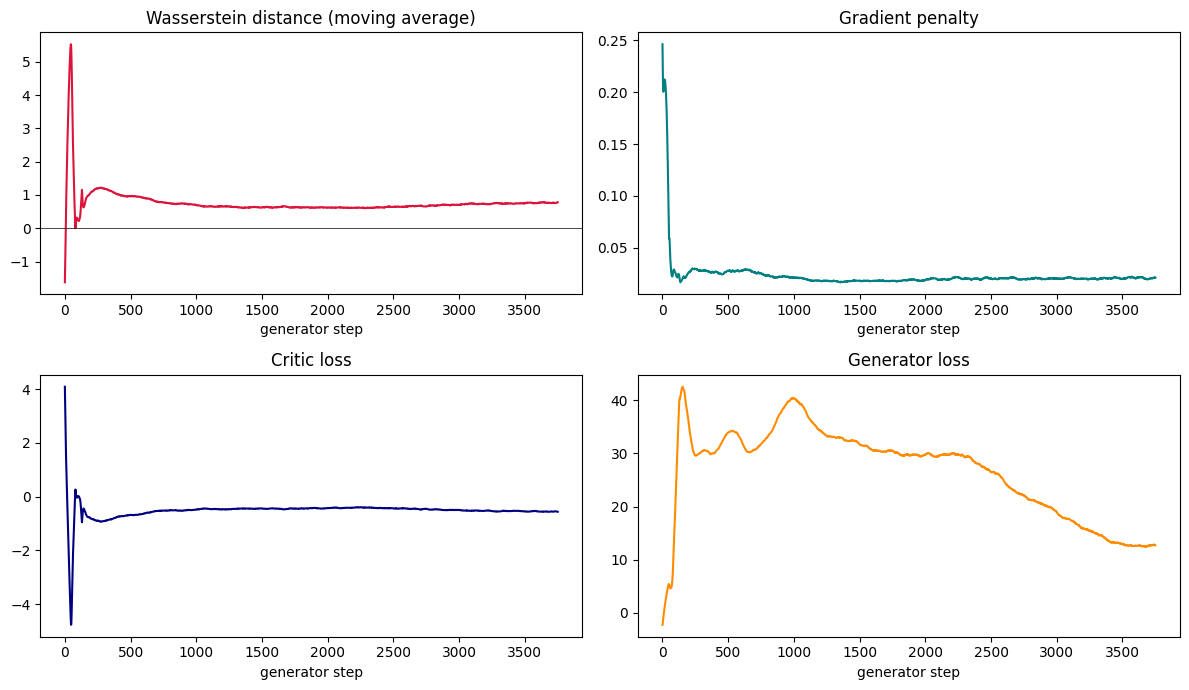

In [16]:
def smooth(x, k=50):
    x = np.asarray(x); k = min(k, len(x))
    return np.convolve(x, np.ones(k)/k, mode="valid") if k > 1 else x

fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0,0].plot(smooth(hist["w_dist"]), color="crimson"); ax[0,0].axhline(0, color="k", lw=.5)
ax[0,0].set_title("Wasserstein distance (moving average)")
ax[0,1].plot(smooth(hist["gp"]), color="teal");        ax[0,1].set_title("Gradient penalty")
ax[1,0].plot(smooth(hist["loss_c"]), color="navy");    ax[1,0].set_title("Critic loss")
ax[1,1].plot(smooth(hist["loss_g"]), color="darkorange"); ax[1,1].set_title("Generator loss")
for a in ax.flat: a.set_xlabel("generator step")
plt.tight_layout(); plt.show()

# Step 2 - Generate samples for evaluation

We draw a batch of sequences from the trained generator and prepare an equally sized batch of real windows
for comparison. All the evaluation is done in the **preprocessed return space** (`u2`, the standardized
Lambert-W space), because that is the space the generator actually operates in. Comparing in this space
isolates the quality of the learned dynamics from the later inverse-transform step.

In [18]:
G.eval()
with torch.no_grad():
    n_gen = 2000
    z = torch.randn(n_gen, 5, days, device=device)
    gen = G(z).cpu().numpy().squeeze(1)          # (n_gen, days) -- u2 space

real_all = X_real.cpu().numpy().squeeze(1)       # (N, days)
ridx = np.random.choice(len(real_all), min(n_gen, len(real_all)), replace=False)
real_sample = real_all[ridx]

gen_flat, real_flat = gen.reshape(-1), real_sample.reshape(-1)
print("generated:", gen.shape, "| real:", real_sample.shape)

generated: (2000, 30) | real: (2000, 30)


# Step 3 - Marginal distribution of returns

This is the most basic quality check: the histogram of generated returns should overlap the histogram of
real returns, **including the tails**. The y-axis is on a log scale so that the rare, extreme moves (the
tails) remain visible instead of being crushed near zero. We also print skewness and kurtosis for a direct
numerical comparison: financial returns are negatively skewed and strongly leptokurtic (kurtosis well above
the Gaussian value of 3), and a good generator should reproduce both.

REAL     skew=-0.191  kurt=3.418
GENERATED skew=-0.178  kurt=3.325


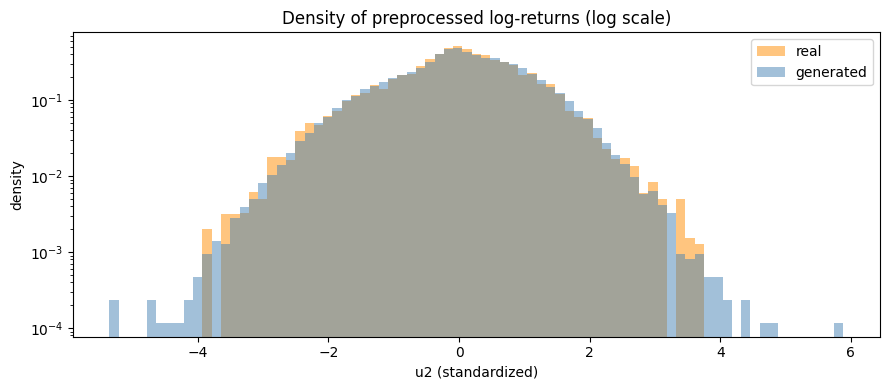

In [20]:
from scipy.stats import skew, kurtosis
print(f"REAL     skew={skew(real_flat):+.3f}  kurt={kurtosis(real_flat, fisher=False):.3f}")
print(f"GENERATED skew={skew(gen_flat):+.3f}  kurt={kurtosis(gen_flat, fisher=False):.3f}")

plt.figure(figsize=(9, 4))
bins = np.linspace(min(real_flat.min(), gen_flat.min()),
                   max(real_flat.max(), gen_flat.max()), 80)
plt.hist(real_flat, bins=bins, density=True, alpha=0.5, label="real", color="darkorange")
plt.hist(gen_flat,  bins=bins, density=True, alpha=0.5, label="generated", color="steelblue")
plt.yscale("log")
plt.title("Density of preprocessed log-returns (log scale)")
plt.xlabel("u2 (standardized)"); plt.ylabel("density"); plt.legend()
plt.tight_layout(); plt.show()

# Step 4 - QQ-plot (tail behaviour)

The quantile-quantile plot compares the quantiles of the generated distribution against those of the real
distribution. Points lying on the diagonal mean the two distributions coincide. Deviations at the extremes
(bottom-left and top-right) reveal differences in the **tails**, the most critical region for financial
data: getting the tails right is what separates a usable risk/hedging simulator from a toy model.

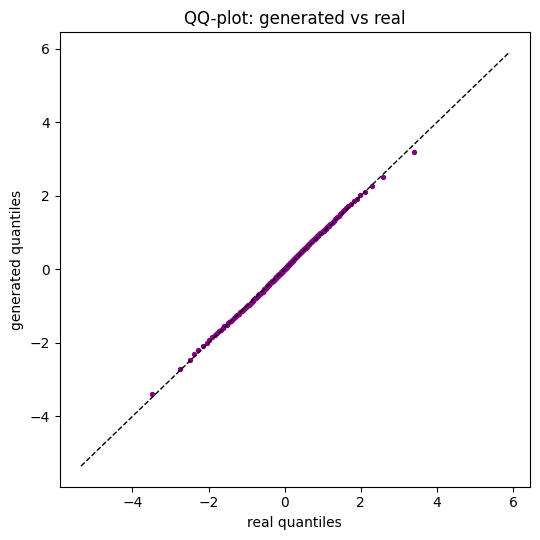

In [21]:
qs = np.linspace(0.001, 0.999, 200)
plt.figure(figsize=(5.5, 5.5))
plt.scatter(np.quantile(real_flat, qs), np.quantile(gen_flat, qs), s=8, color="purple")
lim = [min(real_flat.min(), gen_flat.min()), max(real_flat.max(), gen_flat.max())]
plt.plot(lim, lim, "k--", lw=1)
plt.title("QQ-plot: generated vs real")
plt.xlabel("real quantiles"); plt.ylabel("generated quantiles")
plt.tight_layout(); plt.show()

# Step 5 - Stylized facts: autocorrelations

These are the real tests of a Quant GAN, averaged over all windows:
- **ACF of returns** should be ~ 0 at every lag (returns are essentially unpredictable);
- **ACF of squared returns** should decay slowly (volatility clustering: large moves follow large moves);
- **ACF of absolute returns** shows the same effect, often more cleanly.

With windows of only 30 days the number of usable lags is limited, so we use `max_lag = 15`. A good
generator reproduces all three curves, not just the marginal distribution.

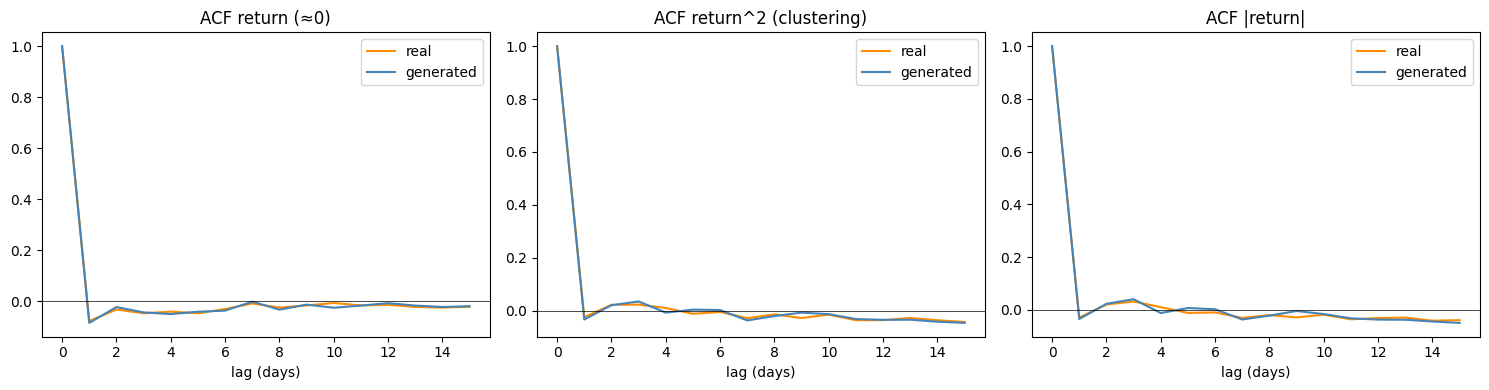

In [22]:
def acf(x, max_lag):
    x = x - x.mean(); n = len(x)
    var = np.dot(x, x) / n
    if var == 0: return np.zeros(max_lag + 1)
    return np.array([np.dot(x[:n-l], x[l:]) / n / var for l in range(max_lag + 1)])

def mean_acf(W, transform, max_lag):
    return np.mean([acf(transform(w), max_lag) for w in W], axis=0)

ml = 15; lags = np.arange(ml + 1)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for k, (title, tr) in enumerate([("ACF return (≈0)", lambda w: w),
                                  ("ACF return^2 (clustering)", lambda w: w**2),
                                  ("ACF |return|", lambda w: np.abs(w))]):
    ax[k].plot(lags, mean_acf(real_sample, tr, ml), label="real", color="darkorange")
    ax[k].plot(lags, mean_acf(gen, tr, ml), label="generated", color="steelblue")
    ax[k].axhline(0, color="k", lw=.5); ax[k].set_title(title)
    ax[k].set_xlabel("lag (days)"); ax[k].legend()
plt.tight_layout(); plt.show()

# Step 6 - Stylized facts: leverage effect

The **leverage effect** is the (typically **negative**) correlation between a return at one instant and the
volatility on the following days: drops tend to raise future volatility more than rallies of the same size
do. We estimate it as the correlation between $r_t$ and $r_{t+\ell}^2$, averaged over the windows. A
negative, slowly decaying curve for both real and generated data indicates the generator captured this
asymmetry.

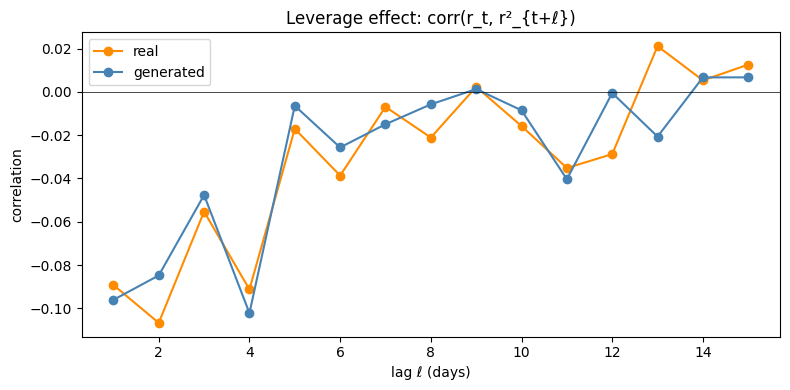

In [23]:
def leverage(W, max_lag):
    out = []
    for l in range(1, max_lag + 1):
        cs = []
        for w in W:
            a, b = w[:-l], w[l:]**2
            if a.std() > 0 and b.std() > 0:
                cs.append(np.corrcoef(a, b)[0, 1])
        out.append(np.mean(cs) if cs else 0.0)
    return np.array(out)

ll = np.arange(1, ml + 1)
plt.figure(figsize=(8, 4))
plt.plot(ll, leverage(real_sample, ml), "o-", label="real", color="darkorange")
plt.plot(ll, leverage(gen, ml), "o-", label="generated", color="steelblue")
plt.axhline(0, color="k", lw=.5)
plt.title("Leverage effect: corr(r_t, r²_{t+ℓ})")
plt.xlabel("lag \u2113 (days)"); plt.ylabel("correlation"); plt.legend()
plt.tight_layout(); plt.show()

# Step 7 - Inverse transform and price reconstruction

The trained generator produces returns in the preprocessed `u2` space. To use it as a scenario simulator
(e.g. for **deep hedging**) we must **invert the preprocessing** using the parameters fitted earlier
(`mu2, sigma2, delta_hat, mu1, sigma1`) together with `forward_lambert_w`, which re-introduces the fat
tails. We then cumulate the resulting log-returns into log-prices and exponentiate to obtain price paths.

generated price paths: (50000, 31)


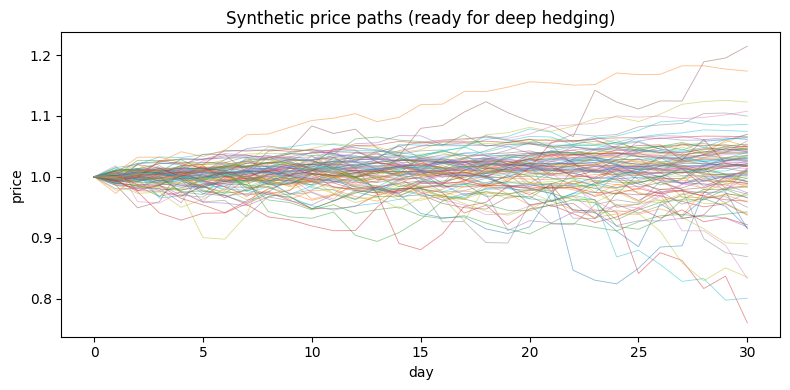

In [45]:
def generate_prices(generator, n_paths, seq_len=days, S0=1.0, device=device):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_paths, 5, seq_len, device=device)
        u2_gen = generator(z).cpu().numpy().squeeze(1)        # u2 space
    # inversion: u2 -> u1 -> r1 -> real log-returns
    u1_gen = u2_gen * sigma2 + mu2
    r1_gen = forward_lambert_w(u1_gen, delta_hat)             # re-introduces the tails
    logret = r1_gen * sigma1 + mu1                            # real returns
    # prices
    logpaths = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(logret, axis=1)], axis=1)
    return S0 * np.exp(logpaths)                              # (n_paths, seq_len+1)

np.random.seed(42)
prices = generate_prices(G, 50000)
print("generated price paths:", prices.shape)

plt.figure(figsize=(8, 4))
for i in np.random.randint(0, 50000, 100):
    plt.plot(prices[i], lw=0.6, alpha=0.5)
plt.title("Synthetic price paths (ready for deep hedging)")
plt.xlabel("day"); plt.ylabel("price"); plt.tight_layout(); plt.show()

df = pd.DataFrame(prices)
df.to_csv("prices.csv", index=False, header=False)

# torch.save(G.state_dict(), "generator.pt")

# Step 8 - Drift sanity check

Finally we inspect the estimated daily drift `mu1`. If it is positive, the underlying data contained an
upward trend, and `exp(mu1 * 30)` reports the expected cumulative price effect over a 30-day window. This
is a sanity check on whether the simulator inherits a directional bias from the historical sample.

In [26]:
print(f"mu1 = {mu1:.6f}")          # if > 0, there is drift in the data
print(f"drift 30gg = {np.exp(mu1 * 30):.4f}")  # expected cumulative effect

mu1 = 0.000337
drift 30gg = 1.0102
